# Transparent Lifecycle Stage Medians and Visuals

This notebook computes stage-duration medians and IQRs for adjusted transparent lifecycle patterns. It uses the final adjusted lifecycle data from `rq1_transparent_lifecycle_order_adjusted.ipynb`, merges severity, assigns transparent pattern IDs (`T1`, `T2`, ...), and creates stage-aligned boxplot visuals with `n` shown beside each severity label.

In [3]:
import contextlib
import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
from matplotlib.patches import Rectangle

In [4]:
ADJUSTED_NOTEBOOK_PATH = Path('../../data/rq1/transparent_data/rq1_transparent_lifecycle_order_adjusted.ipynb')
SEVERITY_PATH = Path('../../data/rq1/repo_with_severity.csv')

severity = pd.read_csv(SEVERITY_PATH)
print('severity:', severity.shape, 'unique CVEs:', severity['CVE_ID'].nunique())
severity['Severity'].value_counts(dropna=False)

severity: (832, 10) unique CVEs: 832


Severity
Medium      608
High        140
Low          47
Critical     36
Unknown       1
Name: count, dtype: int64

## Load Final Adjusted Transparent Lifecycle Data

In [5]:
adjusted_nb = json.loads(ADJUSTED_NOTEBOOK_PATH.read_text())
adjusted_ns = {}

captured_output = io.StringIO()
with contextlib.redirect_stdout(captured_output):
    for i, cell in enumerate(adjusted_nb['cells']):
        if cell.get('cell_type') == 'code':
            source = ''.join(cell.get('source', []))
            exec(compile(source, f'adjusted_notebook_cell_{i}', 'exec'), adjusted_ns)

transparent_lifecycle_order_adjusted_df = adjusted_ns['transparent_lifecycle_order_adjusted_df'].copy()
transparent_lifecycle_summary_adjusted = adjusted_ns['transparent_lifecycle_summary_adjusted'].copy()
manual_excluded_adjusted_df = adjusted_ns.get('manual_excluded_adjusted_df', pd.DataFrame()).copy()

print('adjusted lifecycle rows:', len(transparent_lifecycle_order_adjusted_df))
print('manual excluded rows:', len(manual_excluded_adjusted_df))
transparent_lifecycle_summary_adjusted

adjusted lifecycle rows: 278
manual excluded rows: 1


,First,Second,Third,Fourth,Count,%
0,Report,Fix,Release,Disclosure,216,77.70
1,Report,Fix,Disclosure,Release,26,9.35
2,Disclosure,Report,Fix,Release,13,4.68
3,Fix,Release,Disclosure,GAD,13,4.68
4,Report,Disclosure,Fix,Release,6,2.16
5,Disclosure,Fix,Release,GAD,2,0.72
6,Fix,Disclosure,Release,GAD,2,0.72


## Add Severity and Pattern IDs

In [6]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_levels = severity_order
severity_colors = {
    'Critical': '#d62728',
    'High': '#ff7f0e',
    'Medium': '#4c78a8',
    'Low': '#2ca25f',
    'Unknown': '#8c8c8c',
}

severity_lookup = severity[['CVE_ID', 'Severity']].drop_duplicates(subset=['CVE_ID']).copy()
transparent_order_df = transparent_lifecycle_order_adjusted_df.merge(
    severity_lookup,
    on='CVE_ID',
    how='left',
)

print('Missing Severity:', transparent_order_df['Severity'].isna().sum())
print(transparent_order_df['Severity'].value_counts(dropna=False))

pattern_order_df = transparent_lifecycle_summary_adjusted.copy()
pattern_order_df['Pattern'] = [f'T{i}' for i in range(1, len(pattern_order_df) + 1)]
pattern_key = {
    (row['First'], row['Second'], row['Third'], row['Fourth']): row['Pattern']
    for _, row in pattern_order_df.iterrows()
}

transparent_order_df['Pattern'] = transparent_order_df.apply(
    lambda row: pattern_key[(row['First'], row['Second'], row['Third'], row['Fourth'])],
    axis=1,
)

transition_pattern_titles = {
    row['Pattern']: f"{row['Pattern']}: {row['First']} -> {row['Second']} -> {row['Third']} -> {row['Fourth']} (n={row['Count']})"
    for _, row in pattern_order_df.iterrows()
}

pattern_order_df[['Pattern', 'First', 'Second', 'Third', 'Fourth', 'Count', '%']]

Missing Severity: 0
Severity
Medium      187
High         57
Low          20
Critical     14
Name: count, dtype: int64


,Pattern,First,Second,Third,Fourth,Count,%
0,T1,Report,Fix,Release,Disclosure,216,77.70
1,T2,Report,Fix,Disclosure,Release,26,9.35
2,T3,Disclosure,Report,Fix,Release,13,4.68
3,T4,Fix,Release,Disclosure,GAD,13,4.68
4,T5,Report,Disclosure,Fix,Release,6,2.16
5,T6,Disclosure,Fix,Release,GAD,2,0.72
6,T7,Fix,Disclosure,Release,GAD,2,0.72


## Compute Stage Durations

Durations are computed in days using full timestamps, while the adjusted ordering and pattern labels come from the final adjusted lifecycle notebook.

In [7]:
event_date_columns = {
    'Report': 'Report Date',
    'Fix': 'Fix Date',
    'Release': 'Release Date',
    'Disclosure': 'Disclosure Date',
    'GAD': 'Report Date',
}

for col in ['Report Date', 'Fix Date', 'Release Date', 'Disclosure Date']:
    transparent_order_df[col] = pd.to_datetime(transparent_order_df[col], errors='coerce')


def event_timestamp(row, event_name):
    return row[event_date_columns[event_name]]


def transition_days(row, left_col, right_col):
    left_event = row[left_col]
    right_event = row[right_col]
    left_time = event_timestamp(row, left_event)
    right_time = event_timestamp(row, right_event)
    if pd.isna(left_time) or pd.isna(right_time):
        return np.nan
    return (right_time - left_time).total_seconds() / 86400


transparent_order_df['Days: First -> Second'] = transparent_order_df.apply(
    lambda row: transition_days(row, 'First', 'Second'), axis=1
)
transparent_order_df['Days: Second -> Third'] = transparent_order_df.apply(
    lambda row: transition_days(row, 'Second', 'Third'), axis=1
)
transparent_order_df['Days: Third -> Fourth'] = transparent_order_df.apply(
    lambda row: transition_days(row, 'Third', 'Fourth'), axis=1
)
transparent_order_df['Days: First -> Fourth'] = transparent_order_df.apply(
    lambda row: transition_days(row, 'First', 'Fourth'), axis=1
)

transparent_order_df[[
    'CVE_ID', 'Pattern', 'Severity', 'First', 'Second', 'Third', 'Fourth',
    'Days: First -> Second', 'Days: Second -> Third', 'Days: Third -> Fourth', 'Days: First -> Fourth'
]].head()

,CVE_ID,Pattern,Severity,First,Second,Third,Fourth,Days: First -> Second,Days: Second -> Third,Days: Third -> Fourth,Days: First -> Fourth
0,CVE-2013-4600,T1,Medium,Report,Fix,Release,Disclosure,6.754178,18.850903,30.501852,56.106933
1,CVE-2018-3831,T1,Medium,Report,Fix,Release,Disclosure,-0.001215,0.000000,20.311157,20.309942
2,CVE-2019-16943,T2,Medium,Report,Fix,Disclosure,Release,1.852975,1.491227,39.632951,42.977153
3,CVE-2021-37714,T1,Medium,Report,Fix,Release,Disclosure,0.420440,0.130590,2.347743,2.898773
4,CVE-2020-36282,T1,High,Report,Fix,Release,Disclosure,0.042500,0.908704,127.605602,128.556806


## Median and IQR Tables

In [8]:
def median_iqr_text(values):
    values = values.dropna()
    if values.empty:
        return 'NA'
    return f'{values.median():.2f} [{values.quantile(0.25):.2f}, {values.quantile(0.75):.2f}]'


transparent_stage_timing_table = (
    transparent_order_df
    .groupby(['Pattern', 'Severity', 'First', 'Second', 'Third', 'Fourth'])
    .agg(
        Count=('CVE_ID', 'count'),
        **{
            'First -> Second days, median [IQR]': ('Days: First -> Second', median_iqr_text),
            'Second -> Third days, median [IQR]': ('Days: Second -> Third', median_iqr_text),
            'Third -> Fourth days, median [IQR]': ('Days: Third -> Fourth', median_iqr_text),
            'First -> Fourth days, median [IQR]': ('Days: First -> Fourth', median_iqr_text),
        }
    )
    .reset_index()
)

pattern_order = pattern_order_df['Pattern'].tolist()
transparent_stage_timing_table['Pattern'] = pd.Categorical(
    transparent_stage_timing_table['Pattern'], categories=pattern_order, ordered=True
)
transparent_stage_timing_table['Severity'] = pd.Categorical(
    transparent_stage_timing_table['Severity'], categories=severity_order, ordered=True
)
transparent_stage_timing_table = transparent_stage_timing_table.sort_values(
    ['Pattern', 'Severity']
).reset_index(drop=True)

transparent_stage_timing_table

,Pattern,Severity,First,Second,Third,Fourth,Count,"First -> Second days, median [IQR]","Second -> Third days, median [IQR]","Third -> Fourth days, median [IQR]","First -> Fourth days, median [IQR]"
0,T1,Critical,Report,Fix,Release,Disclosure,10,"2.53 [0.13, 11.57]","3.82 [0.50, 10.05]","10.86 [5.00, 27.04]","35.25 [12.90, 154.65]"
1,T1,High,Report,Fix,Release,Disclosure,42,"0.34 [0.08, 8.20]","11.32 [1.95, 38.55]","59.22 [20.52, 183.90]","82.52 [41.91, 240.61]"
2,T1,Medium,Report,Fix,Release,Disclosure,147,"2.00 [0.13, 18.12]","5.89 [0.42, 26.42]","29.64 [9.06, 84.01]","65.24 [21.43, 182.18]"
3,T1,Low,Report,Fix,Release,Disclosure,17,"4.72 [1.37, 12.46]","10.05 [5.46, 43.34]","65.29 [7.45, 138.39]","101.41 [52.44, 201.78]"
4,T2,Critical,Report,Fix,Disclosure,Release,1,"708.26 [708.26, 708.26]","52.92 [52.92, 52.92]","0.00 [0.00, 0.00]","761.18 [761.18, 761.18]"
5,T2,High,Report,Fix,Disclosure,Release,7,"3.54 [1.48, 22.57]","13.48 [6.85, 49.88]","53.86 [45.68, 125.44]","154.04 [103.31, 164.78]"
6,T2,Medium,Report,Fix,Disclosure,Release,16,"1.15 [0.21, 2.23]","29.89 [7.37, 47.06]","63.63 [15.53, 134.78]","161.42 [41.06, 249.58]"
7,T2,Low,Report,Fix,Disclosure,Release,2,"0.32 [0.22, 0.41]","7.60 [7.12, 8.07]","11.69 [6.18, 17.20]","19.60 [13.52, 25.68]"
8,T3,Critical,Disclosure,Report,Fix,Release,2,"1.79 [1.28, 2.30]","3.36 [2.19, 4.53]","134.72 [90.40, 179.03]","139.87 [94.90, 184.85]"
9,T3,High,Disclosure,Report,Fix,Release,5,"14.81 [3.40, 66.02]","0.86 [0.62, 1.02]","3.64 [2.68, 46.09]","61.92 [6.36, 70.52]"


## Stage-Aligned Boxplot Visuals

Each plot represents one adjusted transparent lifecycle pattern. Severity labels include `n`. There are three local transition axes because transparent patterns have four lifecycle events.

In [9]:
def round_up_to_10(value):
    if pd.isna(value) or value <= 0:
        return 10
    return int(np.ceil(value / 10) * 10)


def transition_stats(values):
    values = values.dropna()
    return {
        'n': len(values),
        'q1': values.quantile(0.25) if len(values) else np.nan,
        'median': values.median() if len(values) else np.nan,
        'q3': values.quantile(0.75) if len(values) else np.nan,
    }


def summary_axis_max(pattern_df, duration_column):
    rows = []
    for severity, group in pattern_df.groupby('Severity', observed=False):
        stats = transition_stats(group[duration_column])
        if stats['n'] > 0:
            rows.append(stats)

    stats_df = pd.DataFrame(rows)
    if stats_df.empty:
        return 10

    base_df = stats_df[stats_df['n'].gt(1)].copy()
    if base_df.empty:
        base_df = stats_df

    visible_max = max(base_df['q3'].max(), base_df['median'].max())
    return round_up_to_10(visible_max * 1.15)


def local_axis_position_linear(value, start_x, end_x, axis_max):
    if pd.isna(value) or axis_max <= 0:
        return start_x
    fraction = min(max(value / axis_max, 0), 1)
    return start_x + fraction * (end_x - start_x)


def rounded_tick_values(axis_max):
    if axis_max <= 40:
        step = 10
    elif axis_max <= 100:
        step = 20
    elif axis_max <= 250:
        step = 50
    elif axis_max <= 500:
        step = 100
    else:
        step = 200

    ticks = list(range(0, int(axis_max) + 1, step))
    if ticks[-1] != axis_max:
        ticks.append(axis_max)
    return sorted(set(ticks))


def draw_rounded_local_axis(ax, start_x, end_x, y, axis_max, label):
    ax.plot([start_x, end_x], [y, y], color='#555555', linewidth=0.9, zorder=1)

    for tick_value in rounded_tick_values(axis_max):
        tick_x = local_axis_position_linear(tick_value, start_x, end_x, axis_max)
        ax.plot([tick_x, tick_x], [y - 0.05, y + 0.05], color='#555555', linewidth=0.8, zorder=1)
        ax.text(
            tick_x,
            y - 0.10,
            f'{tick_value}',
            ha='center',
            va='top',
            fontsize=7.5,
            color='#444444',
        )

    ax.text(
        (start_x + end_x) / 2,
        y - 0.32,
        f'{label} days',
        ha='center',
        va='top',
        fontsize=8,
        color='#333333',
    )


def draw_readable_boxplot_on_axis(ax, start_x, end_x, y, height, values, color, axis_max):
    stats = transition_stats(values)
    if stats['n'] == 0:
        return

    q1_x = local_axis_position_linear(stats['q1'], start_x, end_x, axis_max)
    median_x = local_axis_position_linear(stats['median'], start_x, end_x, axis_max)
    q3_x = local_axis_position_linear(stats['q3'], start_x, end_x, axis_max)

    axis_width = end_x - start_x
    min_box_width = axis_width * 0.42
    raw_left = min(q1_x, q3_x)
    raw_right = max(q1_x, q3_x)
    raw_width = raw_right - raw_left

    if raw_width < min_box_width:
        center_x = median_x
        left_x = center_x - min_box_width / 2
        right_x = center_x + min_box_width / 2
    else:
        left_x = raw_left
        right_x = raw_right

    left_x = max(left_x, start_x + axis_width * 0.02)
    right_x = min(right_x, end_x - axis_width * 0.02)
    if right_x - left_x < min_box_width:
        if left_x <= start_x + axis_width * 0.02:
            right_x = left_x + min_box_width
        else:
            left_x = right_x - min_box_width

    box = Rectangle(
        (left_x, y - height / 2),
        right_x - left_x,
        height,
        facecolor=color,
        edgecolor='#333333',
        linewidth=1.2,
        alpha=0.20,
        zorder=3,
    )
    ax.add_patch(box)

    median_x = min(max(median_x, left_x), right_x)
    ax.plot(
        [median_x, median_x],
        [y - height / 2, y + height / 2],
        color='#111111',
        linewidth=1.9,
        zorder=4,
    )

    whisker_left = max(start_x, left_x - axis_width * 0.16)
    whisker_right = min(end_x, right_x + axis_width * 0.16)
    ax.plot([whisker_left, left_x], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([right_x, whisker_right], [y, y], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_left, whisker_left], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)
    ax.plot([whisker_right, whisker_right], [y - height * 0.22, y + height * 0.22], color='#555555', linewidth=1.0, zorder=2)

    ax.text(
        (left_x + right_x) / 2,
        y,
        f'Median={stats["median"]:.2f}d',
        ha='center',
        va='center',
        fontsize=8.2,
        color='#111111',
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 1.6},
        zorder=6,
    )

    ax.plot([q1_x, q1_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)
    ax.plot([q3_x, q3_x], [y - height / 2, y - height / 2 - 0.12], color='#333333', linewidth=0.8, zorder=4)

    label_base_y = y - height / 2 - 0.18
    close_labels = abs(q3_x - q1_x) < axis_width * 0.18
    if close_labels:
        q1_label_x = q1_x - axis_width * 0.035
        q3_label_x = q3_x + axis_width * 0.035
        q1_label_y = label_base_y
        q3_label_y = label_base_y - 0.18
        q1_ha = 'right'
        q3_ha = 'left'
    else:
        q1_label_x = q1_x
        q3_label_x = q3_x
        q1_label_y = label_base_y
        q3_label_y = label_base_y
        q1_ha = 'center'
        q3_ha = 'center'

    ax.text(
        q1_label_x,
        q1_label_y,
        f'Q1={stats["q1"]:.2f}d',
        ha=q1_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.86, 'pad': 0.9},
        zorder=6,
    )
    ax.text(
        q3_label_x,
        q3_label_y,
        f'Q3={stats["q3"]:.2f}d',
        ha=q3_ha,
        va='top',
        fontsize=7.3,
        color='#333333',
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.86, 'pad': 0.9},
        zorder=6,
    )

In [10]:
minimum_plot_samples = 2


def plot_stage_aligned_transparent_boxes_with_axes(pattern):
    pattern_df = transparent_order_df[transparent_order_df['Pattern'].eq(pattern)].copy()
    if pattern_df.empty:
        print(f'No data for {pattern}')
        return

    stages = [
        pattern_df['First'].iloc[0],
        pattern_df['Second'].iloc[0],
        pattern_df['Third'].iloc[0],
        pattern_df['Fourth'].iloc[0],
    ]
    severity_counts = pattern_df['Severity'].value_counts().to_dict()
    present_severities = [
        severity for severity in severity_levels
        if severity_counts.get(severity, 0) >= minimum_plot_samples
    ]
    pattern_df = pattern_df[pattern_df['Severity'].isin(present_severities)].copy()

    if not present_severities:
        print(f'Skipping {pattern}: no severity groups with n >= {minimum_plot_samples}.')
        return

    axis_max_values = [
        summary_axis_max(pattern_df, 'Days: First -> Second'),
        summary_axis_max(pattern_df, 'Days: Second -> Third'),
        summary_axis_max(pattern_df, 'Days: Third -> Fourth'),
    ]

    row_gap = 1.40
    bottom_row_y = 1.82
    y_positions = {
        severity: bottom_row_y + row_gap * (len(present_severities) - index - 1)
        for index, severity in enumerate(present_severities)
    }

    fig_height = max(4.2, 1.22 * len(present_severities) + 2.6)
    fig, ax = plt.subplots(figsize=(15.2, fig_height))

    stage_x = [1.0, 4.7, 8.4, 12.1]
    axes = [
        (stage_x[0] + 0.52, stage_x[1] - 0.52),
        (stage_x[1] + 0.52, stage_x[2] - 0.52),
        (stage_x[2] + 0.52, stage_x[3] - 0.52),
    ]
    duration_columns = [
        'Days: First -> Second',
        'Days: Second -> Third',
        'Days: Third -> Fourth',
    ]

    header_y = max(y_positions.values()) + 1.16
    axis_y = 0.34
    guide_color = '#2ca25f'

    for x, stage in zip(stage_x, stages):
        ax.text(x, header_y, stage, ha='center', va='bottom', fontsize=15, color='#111111')
        ax.plot([x, x], [axis_y + 0.18, header_y - 0.10], color=guide_color, linewidth=0.9, alpha=0.25, zorder=0)
        ax.scatter([x], [header_y - 0.22], s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

    transition_labels = [
        f'{stages[0]} -> {stages[1]}',
        f'{stages[1]} -> {stages[2]}',
        f'{stages[2]} -> {stages[3]}',
    ]
    for (start_x, end_x), axis_max, label in zip(axes, axis_max_values, transition_labels):
        draw_rounded_local_axis(ax, start_x, end_x, axis_y, axis_max, label)

    for severity in present_severities:
        severity_df = pattern_df[pattern_df['Severity'].eq(severity)].copy()
        y = y_positions[severity]
        n = len(severity_df)
        color = severity_colors.get(severity, '#4c78a8')

        ax.plot(stage_x, [y] * len(stage_x), color=guide_color, linewidth=1.1, alpha=0.50, zorder=1)
        ax.scatter(stage_x, [y] * len(stage_x), s=34, color=guide_color, edgecolor='white', linewidth=0.8, zorder=5)

        for (start_x, end_x), duration_column, axis_max in zip(axes, duration_columns, axis_max_values):
            draw_readable_boxplot_on_axis(
                ax,
                start_x,
                end_x,
                y,
                0.58,
                severity_df[duration_column],
                color,
                axis_max,
            )

        ax.text(
            0.24,
            y,
            f'{severity} (n={n})',
            ha='right',
            va='center',
            fontsize=10,
            color='#111111',
        )

    ax.plot([0.42, 0.42], [axis_y + 0.10, header_y + 0.2], color='#666666', linewidth=1.2)
    ax.set_xlim(-0.90, 13.0)
    ax.set_ylim(-0.18, header_y + 0.38)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(transition_pattern_titles[pattern], fontsize=13, pad=16)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

Excluded from visual because Count < 2:


,Pattern,Severity,Count
0,T2,Critical,1
1,T4,Critical,1
2,T4,Low,1
3,T5,High,1


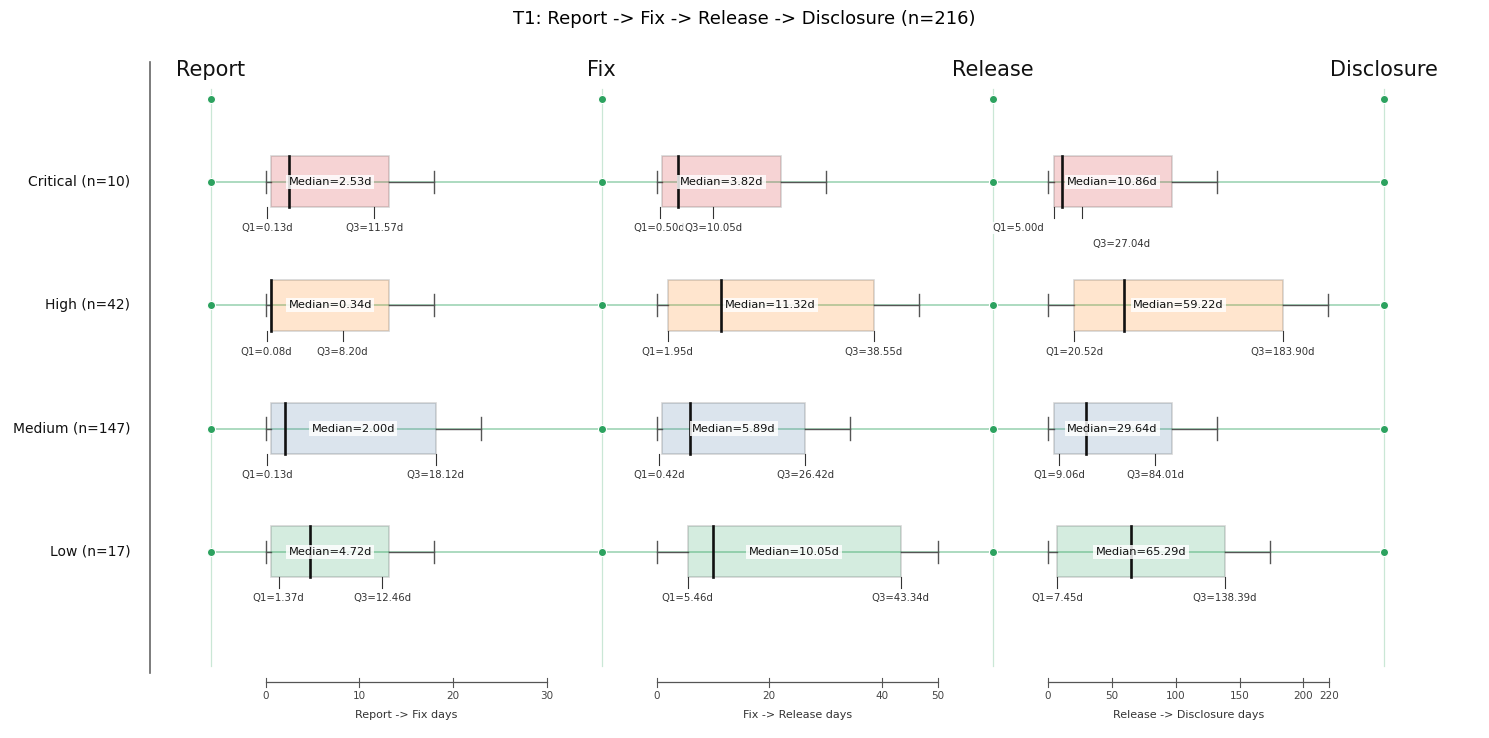

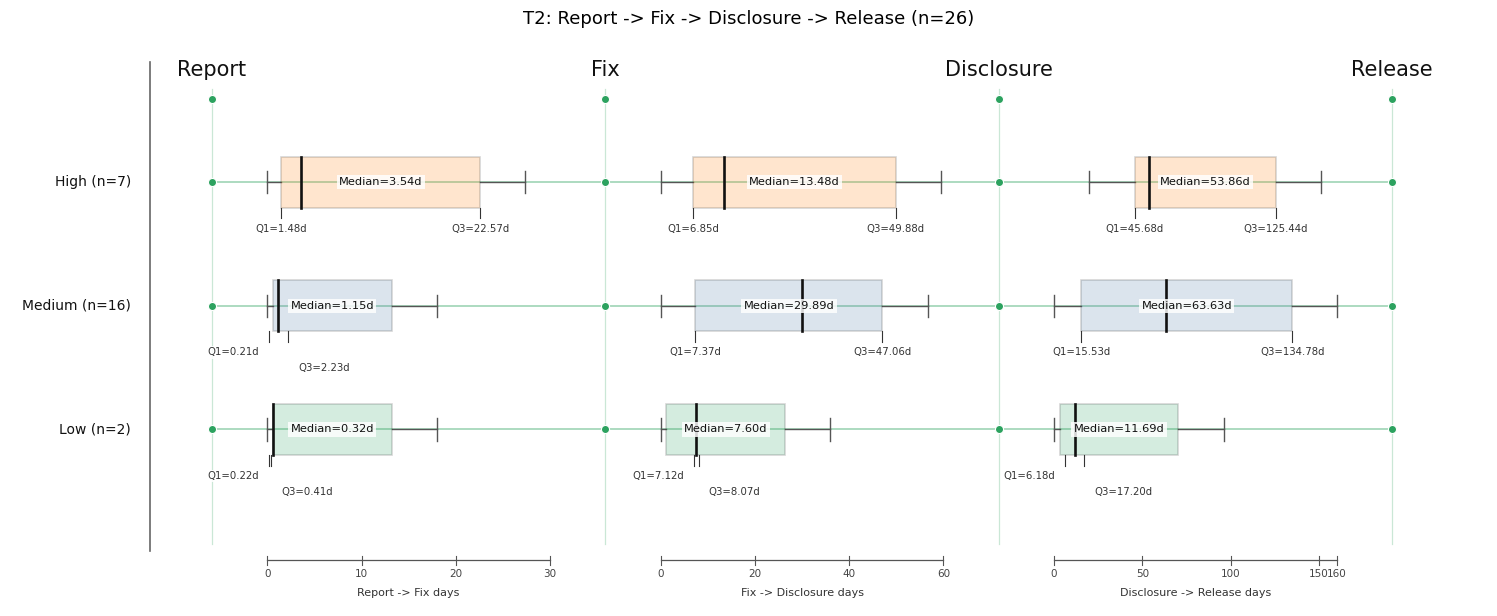

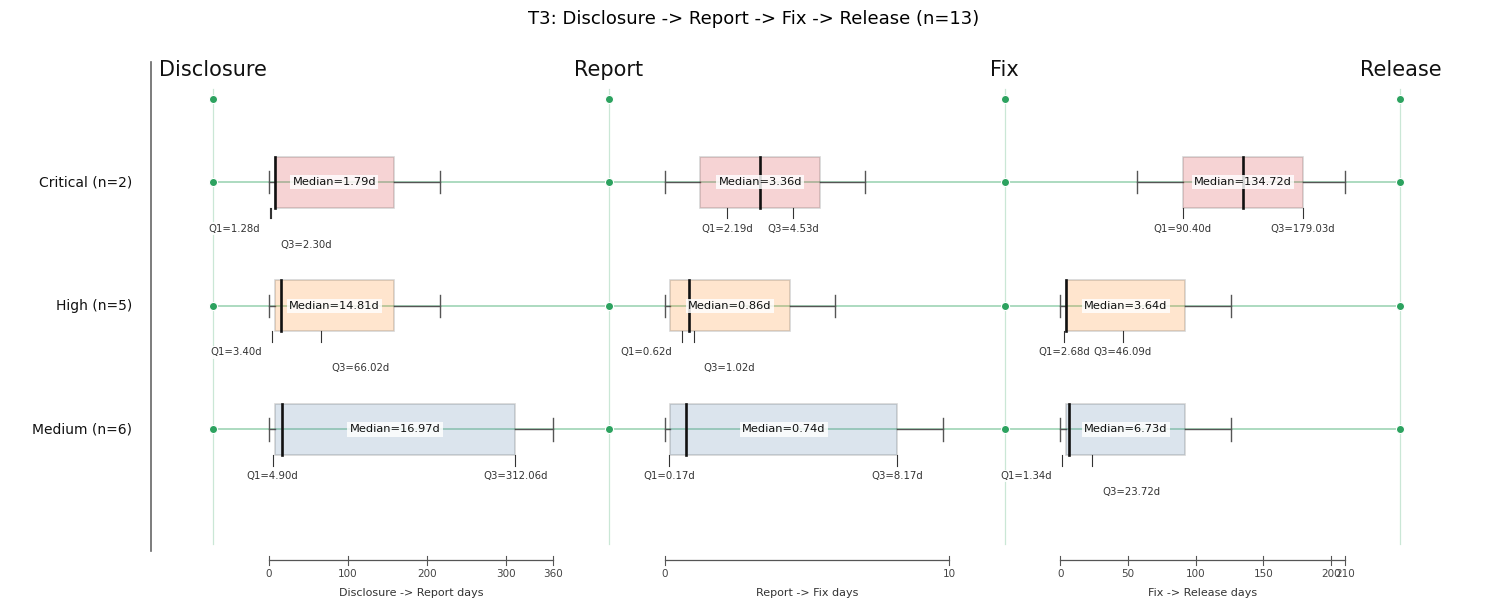

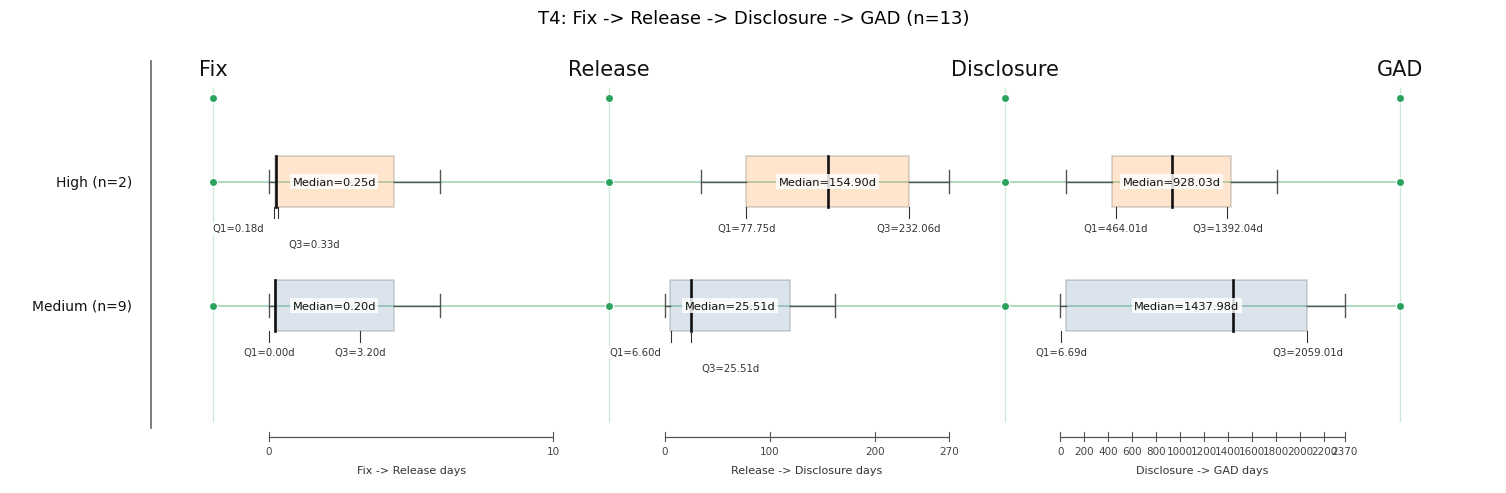

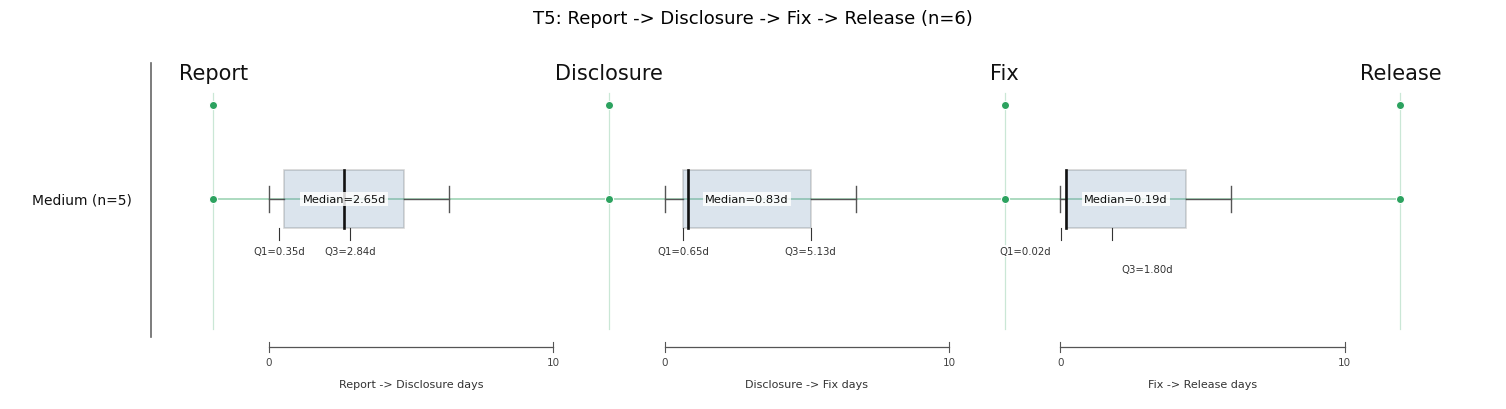

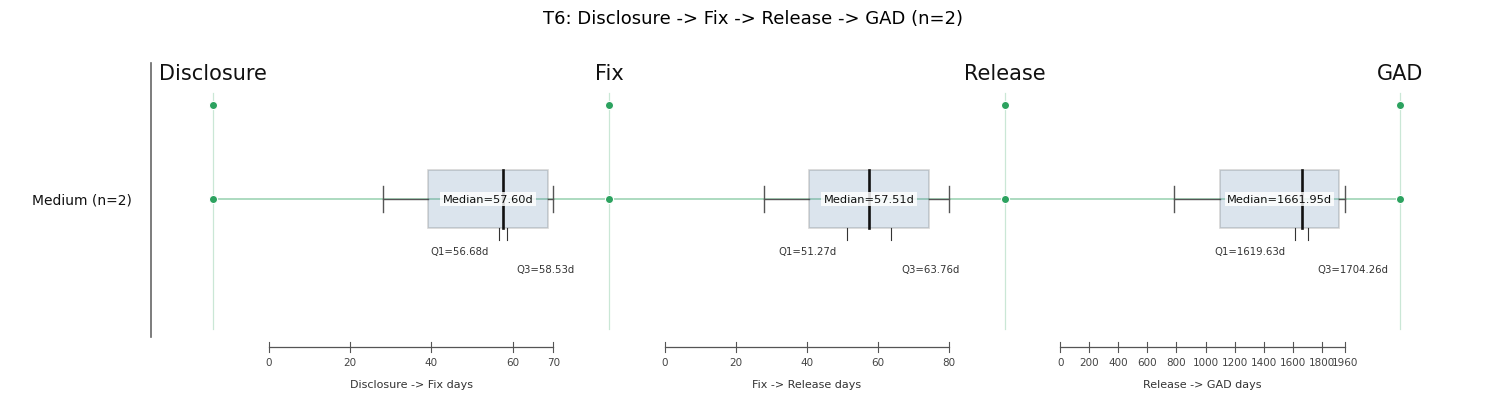

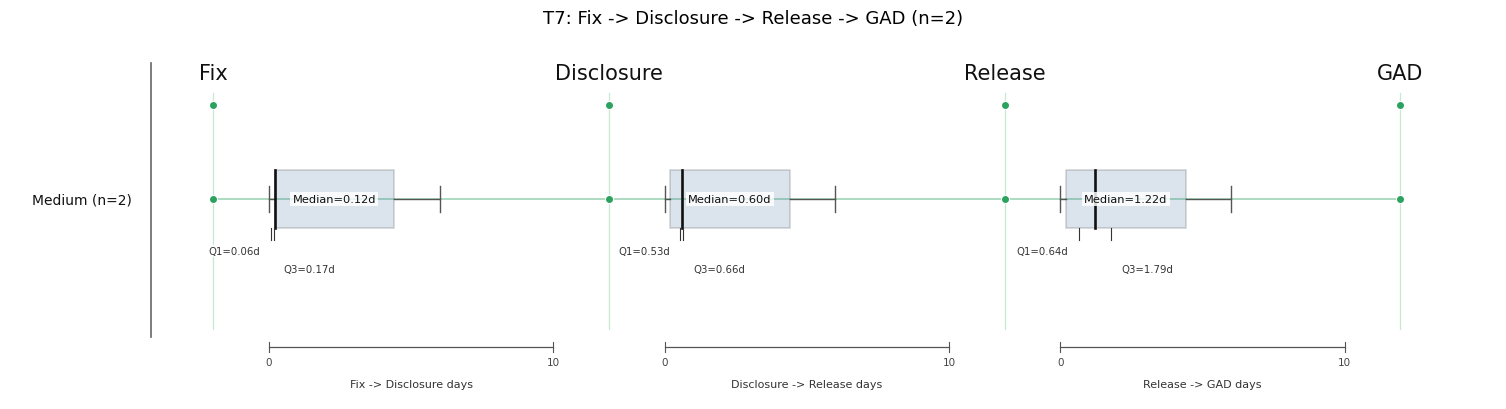

In [11]:
transparent_visual_excluded_groups = transparent_stage_timing_table[
    transparent_stage_timing_table['Count'].lt(minimum_plot_samples)
][['Pattern', 'Severity', 'Count']].copy()

print(f'Excluded from visual because Count < {minimum_plot_samples}:')
if transparent_visual_excluded_groups.empty:
    print('None')
else:
    display(transparent_visual_excluded_groups.reset_index(drop=True))

# Plot every adjusted transparent pattern.
# To plot only selected patterns, replace pattern_order with a list such as ['T1', 'T2'].
for pattern in pattern_order:
    plot_stage_aligned_transparent_boxes_with_axes(pattern)

In [12]:
# No CSV or image files are saved by default. Uncomment only if needed.
# transparent_order_df.to_csv('transparent_stage_medians_source_rows.csv', index=False)
# transparent_stage_timing_table.to_csv('transparent_stage_medians_by_severity.csv', index=False)